# 16_信息论-相对熵

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


本节咱们来接介绍一下相对熵\~

### 什么是相对熵？

相对熵（Relative Entropy），也叫KL散度（Kullback-Leibler Divergence），是用来衡量两个概率分布之间差别的一个量。

#### 举个例子：

假设你是一个侦探，有两个嫌疑人A和B：

- 你原来认为A有70%的可能是罪犯，B是30%（这就是你原来的“信念”分布 P）。
- 后来你得到了一些新线索，改变了你的看法：你现在认为A是40%，B是60%（这是新的分布 Q）。

相对熵就是用来衡量：**你从原来的看法（P）变成新的看法（Q），这个“改变”的代价有多大？**

#### 相对熵的公式（先放着，看不懂没关系）


$$
D_{KL}(P || Q) = \sum_x P(x) \log \frac{P(x)}{Q(x)}
$$


这个看起来复杂，但你只需要记住一点：

> P是你原来的认识，Q是你现在的新认识，KL散度告诉你：如果你还用旧认识（P）来解释现实（其实是Q），你会有多“误判”。\*

我们进一步讲：

- 假设你正在猜一个硬币是“正面”还是“反面”。
- 如果你以为这个硬币是**公平的**（P：正面0.5，反面0.5），
- 但其实它是**偏的**（Q：正面0.9，反面0.1），
- 你一直按“公平”的认知去猜，那你会经常猜错。
- 相对熵就是：**你错认了一个偏硬币是公平的，带来的“信息损失”是多少？**

### 一个简单数字例子

假设我们有：

- P（原来的看法）：正面0.5，反面0.5
- Q（实际分布）：正面0.9，反面0.1

我们来算一算 KL 散度：


$$
D_{KL}(P || Q) = 0.5 \cdot \log\left(\frac{0.5}{0.9}\right) + 0.5 \cdot \log\left(\frac{0.5}{0.1}\right)
$$


大概值是：


$$
0.5 \cdot (-0.152) + 0.5 \cdot (0.699) = -0.076 + 0.3495 = 0.2735
$$


这个 0.27 表示，如果你还用原来的看法 P 来处理现在实际是 Q 的情况，每次会平均损失约 0.27 个比特的信息。

## 原理详解

### 1. 背景和基本概念

假设随机变量 $X$ 取值于集合 $\mathcal{X}$，有两个概率分布：

- $P = \{ P(x) \mid x \in \mathcal{X} \}$，真实分布（或目标分布）
- $Q = \{ Q(x) \mid x \in \mathcal{X} \}$，近似分布（或模型分布）

两个分布满足：


$$
\sum_{x \in \mathcal{X}} P(x) = 1, \quad \sum_{x \in \mathcal{X}} Q(x) = 1
$$


且对所有 $x$，有 $P(x) \geq 0$, $Q(x) > 0$（防止除零和对数无定义）。

### 2. 信息量和熵的基础

**单个事件的信息量**：

根据信息论基本思想，一个概率为 $p$ 的事件的信息量定义为：


$$
I(p) = -\log p
$$


解释：事件越稀有，信息量越大。

**随机变量的信息熵：**

整个分布 $P$ 的**平均信息量**，即熵，定义为：


$$
H(P) = \mathbb{E}_P[-\log P(X)] = -\sum_x P(x) \log P(x)
$$


它刻画了随机变量的平均不确定性。

### 3. 交叉熵：用错误的分布编码的信息长度

如果我们用分布 $Q$ 来编码真实分布 $P$ 的数据，平均编码长度是：


$$
H(P, Q) = -\sum_x P(x) \log Q(x)
$$


注意这不是熵，因为编码分布 $Q$ 不同于真实分布 $P$。

### 4. 相对熵（KL散度）的定义和物理意义

**定义：**  
$D_{KL}(P \parallel Q) = \sum_x P(x) \log \frac{P(x)}{Q(x)}$

**物理意义：**

- 它表示：使用错误的分布 $Q$ 来编码真实分布 $P$ 时，额外增加的平均编码长度（信息损失）。
- 等价于：$D_{KL}(P \parallel Q) = H(P, Q) - H(P)$
- 当 $P=Q$ 时，KL散度为零；否则正值。

### 5. 核心公式

**从熵和交叉熵定义出发**：

1. 真实分布 $P$ 的熵：


$$
H(P) = -\sum_x P(x) \log P(x)
$$


1. 用分布 $Q$ 编码的交叉熵：


$$
H(P, Q) = -\sum_x P(x) \log Q(x)
$$


1. 相对熵定义为：


$$
D_{KL}(P \parallel Q) := H(P, Q) - H(P)
$$


带入上面两式得：


$$
D_{KL}(P \parallel Q) = -\sum_x P(x) \log Q(x) + \sum_x P(x) \log P(x) = \sum_x P(x) \log \frac{P(x)}{Q(x)}
$$


**证明非负性（Gibbs不等式）**：

利用**凸函数的性质**和**Jensen不等式**，证明 $D_{KL}(P \parallel Q) \geq 0$：

1. 函数 $f(t) = -\log t$ 是凸函数。
2. 应用Jensen不等式：


$$
-\sum_x P(x) \log \frac{Q(x)}{P(x)} \geq -\log \sum_x P(x) \frac{Q(x)}{P(x)} = -\log \sum_x Q(x) = -\log 1 = 0
$$


1. 两边取负号：


$$
\sum_x P(x) \log \frac{P(x)}{Q(x)} \geq 0
$$


等号成立当且仅当 $\frac{P(x)}{Q(x)} = 1$ 对所有 $x$ 成立，即 $P=Q$。

**解释非对称性：**

由于 $\log \frac{P(x)}{Q(x)} \neq \log \frac{Q(x)}{P(x)}$，所以


$$
D_{KL}(P \parallel Q) \neq D_{KL}(Q \parallel P)
$$


这体现了KL散度不是严格意义上的距离（不满足对称性），它衡量的是“从分布 $Q$ 到分布 $P$ 的信息损失”。

### 6. 连续分布下的相对熵定义

如果随机变量 $X$ 是连续的，概率密度函数为 $p(x)$, $q(x)$，则相对熵定义为：


$$
D_{KL}(P \parallel Q) = \int_{\mathcal{X}} p(x) \log \frac{p(x)}{q(x)} \, dx
$$


注意积分范围覆盖所有可能取值。

### 7. 计算相对熵的算法流程

假设我们手中有两个离散概率分布 $P, Q$：

**输入**：

$P = \{ p_i \}_{i=1}^n$, 满足 $\sum_i p_i = 1$

$Q = \{ q_i \}_{i=1}^n$, 满足 $\sum_i q_i = 1$, 且所有 $q_i > 0$

**计算步骤**：

1. **验证输入合法性**：

   - 确认所有概率非负且归一化。
   - 防止 $q_i = 0$ 造成除零。
2. **计算对数比值**：
3. 对每个事件 $i$，计算：


$$
r_i = \log \frac{p_i}{q_i}
$$


1. **加权求和**：
2. 计算：


$$
D_{KL}(P \parallel Q) = \sum_{i=1}^n p_i \cdot r_i = \sum_{i=1}^n p_i \log \frac{p_i}{q_i}
$$


1. **输出结果**。

**注意事项**：

- 若 $p_i = 0$，对应项 $p_i \log \frac{p_i}{q_i} = 0$，这是极限情况，通常处理为0。
- 若 $q_i = 0$ 且 $p_i > 0$，则 $D_{KL}(P \parallel Q) = +\infty$，表示$Q$完全忽略了$P$发生的事件。

### 8. 举例说明

假设 $X$ 只有两个状态：$x_1, x_2$，

其中：$P = (0.6, 0.4), \quad Q = (0.5, 0.5)$

计算：$D_{KL}(P \parallel Q) = 0.6 \log \frac{0.6}{0.5} + 0.4 \log \frac{0.4}{0.5}$

用自然对数：


$$
= 0.6 \times 0.1823 + 0.4 \times (-0.2231) = 0.1094 - 0.0892 = 0.0202
$$


说明 $Q$ 和 $P$ 的差异较小，使用 $Q$ 近似 $P$ 会产生约 0.02 nat 的信息损失。

## 完整案例

这里，咱们设计一个多分类问题，模拟两个概率分布（真实分布P和预测分布Q）。

用多个类别（比如10个类别）来体现复杂度。

KL divergence D_KL(P || Q1) = 0.0192
KL divergence D_KL(P || Q2) = 0.2021


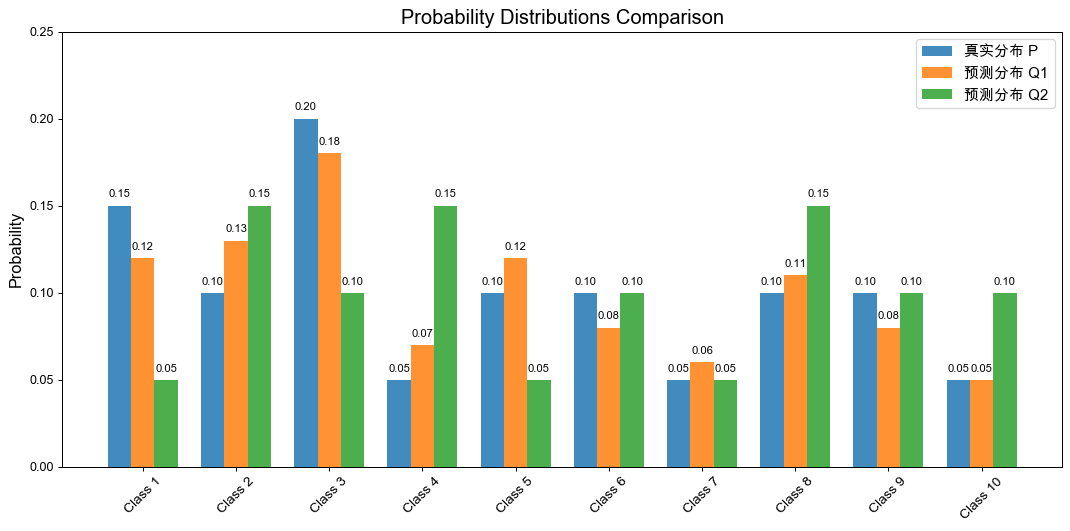

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# 1. 构造两个多分类概率分布
# 假设真实分布 P 和两个预测分布 Q1, Q2
num_classes = 10
classes = [f'Class {i+1}' for i in range(num_classes)]

# 真实分布 P：偏向几个类别
P = np.array([0.15, 0.10, 0.20, 0.05, 0.10, 0.10, 0.05, 0.10, 0.10, 0.05])
P /= P.sum()  # 确保归一化

# 预测分布 Q1：比较接近真实分布
Q1 = np.array([0.12, 0.13, 0.18, 0.07, 0.12, 0.08, 0.06, 0.11, 0.08, 0.05])
Q1 /= Q1.sum()

# 预测分布 Q2：明显偏离真实分布
Q2 = np.array([0.05, 0.15, 0.10, 0.15, 0.05, 0.10, 0.05, 0.15, 0.10, 0.10])
Q2 /= Q2.sum()

# 2. 计算KL散度函数（数值稳定）
def kl_divergence(P, Q, epsilon=1e-12):
    """
    计算KL散度 D_KL(P || Q)
    增加epsilon避免log(0)和除零
    """
    P = np.clip(P, epsilon, 1)
    Q = np.clip(Q, epsilon, 1)
    return np.sum(P * np.log(P / Q))

# 3. 计算KL散度
kl_Q1 = kl_divergence(P, Q1)
kl_Q2 = kl_divergence(P, Q2)

print(f"KL divergence D_KL(P || Q1) = {kl_Q1:.4f}")
print(f"KL divergence D_KL(P || Q2) = {kl_Q2:.4f}")

# 4. 可视化概率分布
x = np.arange(num_classes)
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width, P, width, label='真实分布 P', alpha=0.85)
bars2 = ax.bar(x, Q1, width, label='预测分布 Q1', alpha=0.85)
bars3 = ax.bar(x + width, Q2, width, label='预测分布 Q2', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=45, fontsize=11)
ax.set_ylim(0, 0.25)
ax.set_ylabel('Probability', fontsize=13)
ax.set_title('Probability Distributions Comparison', fontsize=16)
ax.legend(fontsize=12)

# 显示每个柱的数值
def autolabel(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 5),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(bars1)
autolabel(bars2)
autolabel(bars3)

plt.tight_layout()
plt.show()

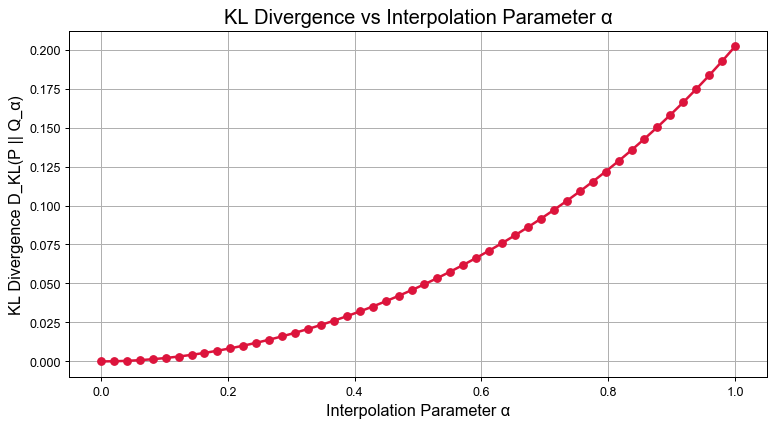

In [3]:
# 5. 模拟参数变化，观察KL散度变化趋势
# 设计一个调节参数 alpha，在P和Q2之间插值，计算KL散度

alphas = np.linspace(0, 1, 50)
kl_values = []

for alpha in alphas:
    Q_alpha = alpha * Q2 + (1 - alpha) * P  # 插值分布
    Q_alpha /= Q_alpha.sum()
    kl = kl_divergence(P, Q_alpha)
    kl_values.append(kl)

# 绘制KL散度曲线
plt.figure(figsize=(10, 5))
plt.plot(alphas, kl_values, marker='o', color='crimson', linewidth=2)
plt.xlabel('Interpolation Parameter α', fontsize=13)
plt.ylabel('KL Divergence D_KL(P || Q_α)', fontsize=13)
plt.title('KL Divergence vs Interpolation Parameter α', fontsize=16)
plt.grid(True)
plt.show()

### 1. 构造概率分布

- 设计10分类问题，让真实分布 $P$ 偏向少数几个类别，模拟现实情况中“类别不均衡”的情形。
- 预测分布 $Q1$ 和 $Q2$ 分别代表较好和较差的预测结果。
- 归一化保证所有概率和为1。

这让我们可以通过KL散度定量比较预测分布与真实分布的差异。

### 2. 定义KL散度函数

- 使用 $\epsilon$ 防止0概率导致对数无穷的情况，增加数值稳定性。
- 直接用numpy向量化计算，提高性能。
- 计算公式：


$$
D_{KL}(P || Q) = \sum_i P_i \log \frac{P_i}{Q_i}
$$


### 3. 计算KL散度值

- 计算 $D_{KL}(P||Q1)$ 和 $D_{KL}(P||Q2)$
- 结果显示，$Q1$ 比 $Q2$ 更接近真实分布（KL散度更小）

### 4. 可视化概率分布

- 用三组并列柱状图对比 $P, Q1, Q2$
- 每个柱子上显示具体概率数值

![原文参考图，当前结果见代码输出](attachments/img_006.png)

- 直观显示两个预测分布与真实分布的差异。
- 观察KL散度与概率分布形状的对应关系。

### 5. 模拟参数变化，观察KL散度趋势

- 用插值参数 $\alpha \in [0,1]$ 在 $P$ 和 $Q2$ 之间线性插值，构造新分布 $Q_\alpha$。
- 计算对应的KL散度，画出变化曲线。

**分析**：

- 当 $\alpha=0$ 时，$Q_\alpha = P$，KL散度为0。
- 随着 $\alpha$ 增大，预测分布偏离真实分布，KL散度增加，体现KL散度对预测偏差的敏感性。

## 模型分析

**相对熵优缺点**

**优点**：

1. **直观度量概率分布差异**：KL散度能够定量反映两个概率分布之间的差异，特别是从真实分布$P$到预测分布$Q$的信息损失，有明确的信息论意义。
2. **非对称性体现方向性**：KL散度不对称，能区分“用错误模型编码真实分布”的不同情况，这在机器学习中经常用来度量模型预测与真实标签的差异。
3. **易于计算和优化**：该案例中利用向量化实现，计算效率高，且与交叉熵损失函数密切相关，方便应用在深度学习训练中。
4. **适应离散和连续分布**：KL散度定义灵活，既可用于离散概率，也可推广到连续概率密度，应用广泛。

**缺点**：

1. **不对称，不满足距离性质**：由于KL散度不对称，不能作为真正的距离度量，可能导致在某些应用中不易解释。
2. **数值不稳定风险**：当$Q(x)$接近0而$P(x)$不为0时，KL散度趋向无穷大，可能引发数值计算问题，需要额外数值稳定技巧。
3. **对分布尾部敏感**：KL散度对$P$中有概率但$Q$中无概率的事件特别敏感，导致极端值，这在训练数据不完整或模型欠拟合时可能不太稳健。
4. **难以捕捉整体形态相似度**：有时候两个分布形态很接近，但KL散度仍较大，尤其是概率集中但位置稍偏时，不够“宽容”。

## 最后

相对熵就是用来衡量两个概率分布差多远的一种“距离”，可以理解成如果你拿错的分布去压缩数据会多花掉多少信息量，而且它是有方向的，换个顺序算出来的值会不一样。